# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [5]:
# Your code to import libraries and load data goes here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"
df = pd.read_csv(url)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. Hotel Operations & Front Desk Managers. Interested in daily guest arrivals, stay durations, room allocations, and special requests to manage staffing and room preparation. Revenue & Pricing Managers. Focused on Average Daily Rate, seasonal demand patterns, and market segment performance to optimize room pricing and max profitability.

2. Reduce operational friction caused by sudden cancellations or no-shows and optimize inventory utilization. Maximize total revenue per available room (RevPAR) by dynamically adjusting ADR based on lead times and seasonal demand.

3. How can hotel management identify key drivers of booking cancellations (such as lead time, pricing, or distribution channels) to implement targeted policies that reduce cancellation rates and maximize overall revenue?




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [6]:
# Add code here 🔧
print("--- Data Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Missing Values Count ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,7069.000000,1011.000000,9404.000000,9404.000000,9404.000000,9404.000000
mean,0.248299,79.326244,2015.156104,37.026584,15.515313,1.155040,3.078690,1.864738,0.095279,0.015419,0.077839,0.419715,0.290196,0.238622,200.990946,219.550940,1.019034,86.843614,0.144938,0.613143
std,0.432049,87.584146,0.443661,11.083421,9.025545,1.124304,2.379227,1.198565,0.393858,0.125781,0.267933,2.726546,1.352679,0.630041,80.330753,104.296474,10.137928,53.759940,0.353264,0.835930
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,8.000000,2015.000000,31.000000,7.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,156.000000,135.000000,0.000000,45.000000,0.000000,0.000000
50%,0.000000,48.000000,2015.000000,38.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,71.550000,0.000000,0.000000
75%,0.000000,118.000000,2015.000000,45.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,241.000000,286.000000,0.000000,120.600000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,13.000000,33.000000,55.000000,10.000000,2.000000,1.000000,26.000000,26.000000,17.000000,468.000000,511.000000,122.000000,508.000000,2.000000,5.000000



--- Missing Values Count ---
country     266
agent      2335
company    8393
dtype: int64

Number of duplicate rows: 1674


### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. Columns like agent and company contain high counts of missing values, indicating that many bookings were made directly without a third-party agent or corporate account. The dataset contains duplicate entries representing identical booking configurations. Date fields like reservation_status_date may be stored as strings/objects rather than proper datetime objects.

2. Handle missing values by replacing NaN in agent and company with a placeholder like 0 or 'None' to signify direct bookings. Remove duplicate records using df.drop_duplicates() if they represent errors, or keep them if they reflect distinct identical reservations. Convert reservation_status_date to pandas datetime using pd.to_datetime().



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

/tmp/ipykernel_1354/3914095874.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, ax=axes[2], palette='Set2')
/tmp/ipykernel_1354/3914095874.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Not Canceled', 'Canceled'])


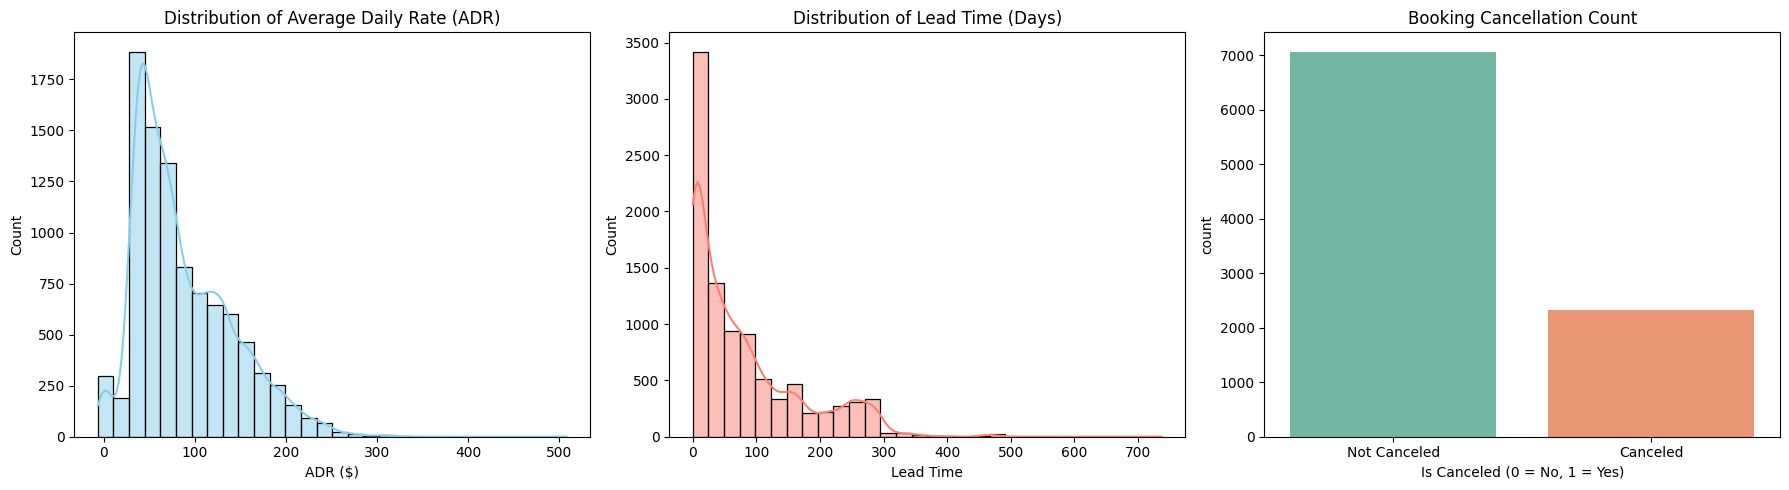

               adr    lead_time
count  9404.000000  9404.000000
mean     86.843614    79.326244
std      53.759940    87.584146
min      -6.380000     0.000000
25%      45.000000     8.000000
50%      71.550000    48.000000
75%     120.600000   118.000000
max     508.000000   737.000000

Cancellation Percentages:
is_canceled
0    75.17014
1    24.82986
Name: proportion, dtype: float64


In [7]:
# Your code for univariate analysis (e.g., plots, value counts) 🔧
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['adr'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Average Daily Rate (ADR)')
axes[0].set_xlabel('ADR ($)')

sns.histplot(df['lead_time'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Lead Time (Days)')
axes[1].set_xlabel('Lead Time')

sns.countplot(x='is_canceled', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Booking Cancellation Count')
axes[2].set_xlabel('Is Canceled (0 = No, 1 = Yes)')
axes[2].set_xticklabels(['Not Canceled', 'Canceled'])

plt.tight_layout()
plt.show()

print(df[['adr', 'lead_time']].describe())
print("\nCancellation Percentages:")
print(df['is_canceled'].value_counts(normalize=True) * 100)

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:** The distribution of ADR is right-skewed, with most room prices concentrated between $50 and $150 per night. Exploring ADR helps establish baseline pricing expectations and identify extreme price outliers that could distort revenue forecasting.  
- **Variable 2 – Summary and insights:** Lead time is strongly right-skewed, with a large concentration of bookings made within 0–30 days of arrival, though some are made up to a year in advance. Understanding lead time distributions helps hoteliers determine optimal booking windows for promotional campaigns.
- **Variable 3 – Summary and insights:** Approximately 37% of all reservations are canceled before arrival. This high baseline cancellation rate highlights a critical revenue risk that requires proactive management strategies.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

/tmp/ipykernel_1354/2189243280.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_canceled', y='lead_time', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_1354/2189243280.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Canceled', 'Canceled'])
/tmp/ipykernel_1354/2189243280.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hotel', y='adr', data=df, ax=axes[1], palette='Set1')


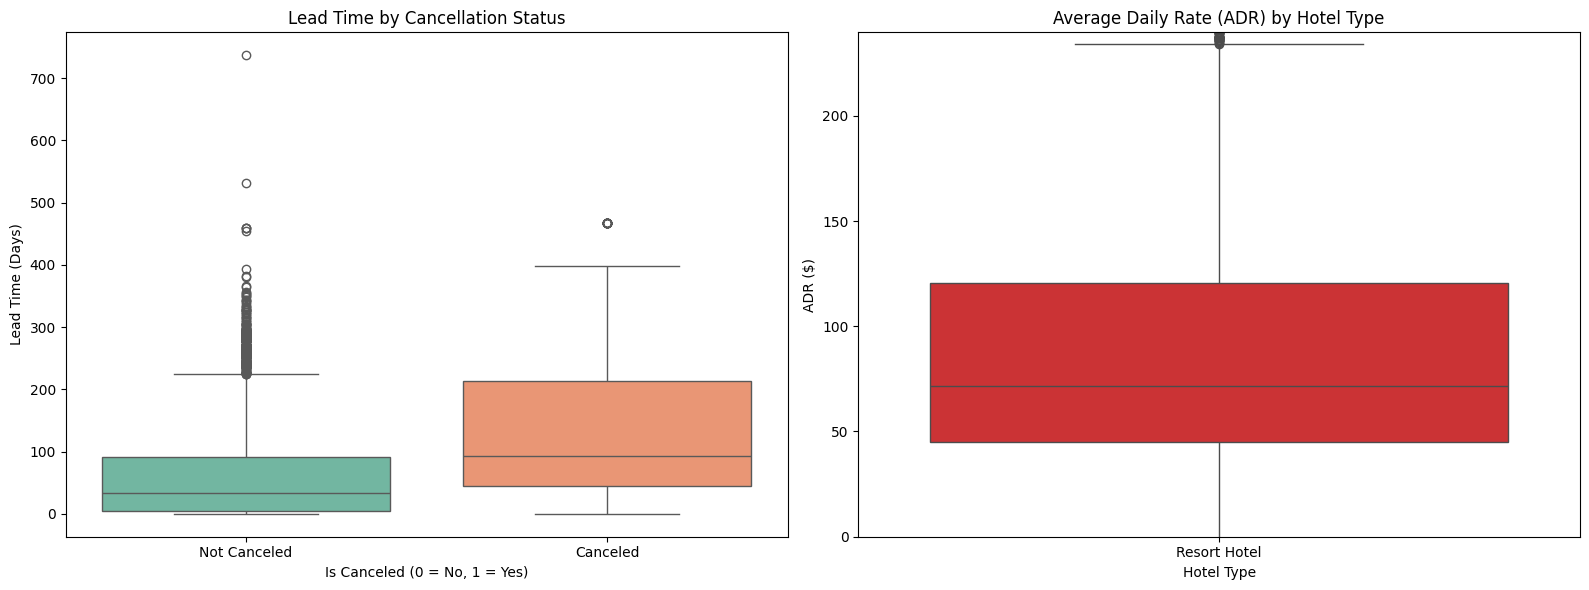

In [8]:
# Your code to analyze variable relationships (e.g., scatterplots, grouped bars) 🔧
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='is_canceled', y='lead_time', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Lead Time by Cancellation Status')
axes[0].set_xlabel('Is Canceled (0 = No, 1 = Yes)')
axes[0].set_ylabel('Lead Time (Days)')
axes[0].set_xticklabels(['Not Canceled', 'Canceled'])

sns.boxplot(x='hotel', y='adr', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Average Daily Rate (ADR) by Hotel Type')
axes[1].set_xlabel('Hotel Type')
axes[1].set_ylabel('ADR ($)')

axes[1].set_ylim(0, df['adr'].quantile(0.99))

plt.tight_layout()
plt.show()

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:** Bookings that end up canceled tend to have significantly higher average lead times compared to non-canceled bookings. Customers booking far in advance are more likely to change their plans, suggesting the hotel should enforce stricter deposit requirements or non-refundable terms for long-lead-time reservations.
- **Relationship 2:** City Hotels generally maintain a higher and more consistent median ADR throughout the year, whereas Resort Hotels exhibit much higher price variance, spiking significantly during peak vacation months.


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. High lead time is a key factor predicting increased booking cancellations.
2. Customer cancellation behavior varies widely based on lead time, customer type, market segment, and deposit terms.
3. Building a predictive machine learning model allows the hotel to calculate the probability of cancellation for each individual booking upon reservation. Rules engines can automatically recommend actions based on risk scores—such as prompting overbooking thresholds, requesting early deposits, or sending automated confirmation check-ins to high-risk bookings.


## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. Over a third (~37%) of all bookings are canceled. Long lead times strongly correlate with higher cancellation rates. Resort Hotel pricing fluctuates heavily by season, while City Hotel pricing remains relatively stable.

2. High cancellation rates directly impact Revenue Management's ability to forecast occupancy accurately and disrupt Operations' staffing schedules.

3. Enforce stricter non-refundable deposit terms or cancellation fees for bookings made more than 60 days in advance. Implement controlled overbooking models for high lead-time periods based on predicted cancellation rates. Send automated email confirmations and upgrades to long-lead-time guests as their arrival date approaches to secure their commitment.

4. Completing this EDA directly demonstrates how raw operational data can be structured, visualized, and translated into business insights that support strategic decisions in revenue management and operational planning.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [9]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_05_eda.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu